In [1]:
# @title
import scipy.stats as st

def test_bondad_ajuste(muestra: list[float]):
    # ---------- Prueba contra distribución Weibull
    # Se estiman los parámetros de la Weibull según la muestra
    par_weibull = st.exponweib.fit(muestra)

    # Realiza el test Kolmogorov-Smirnov
    d_weibull, p_valor_weibull = st.kstest(muestra, st.exponweib.cdf, args=par_weibull)

    print(f"Ajuste a distribución Weibull:")
    print(f"- Estadístico D : {d_weibull:.4f}")
    print(f"- P-valor       : {p_valor_weibull:.4e}")

    # ---------- Prueba contra distribución Gamma
    # Se estiman los parámetros de la Gamma según la muestra
    par_gamma = st.gamma.fit(muestra)

    # Realiza el test Kolmogorov-Smirnov
    d_gamma, p_valor_gamma = st.kstest(muestra, st.gamma.cdf, args=par_gamma)

    print()
    print(f"Ajuste a distribución Gamma:")
    print(f"- Estadístico D : {d_gamma:.4f}")
    print(f"- P-valor       : {p_valor_gamma:.4e}")

# GUÍA DE TRABAJO ESPECIAL

### Ejercicio 1. Problema de Reparación con un operario
Un supermercado pequeño cuenta con $N$ cajas registradoras en servicio y con $S$ máquinas de repuesto, todas ellas de idéntica marca, modelo y antigüedad. Además el supermercado cuenta con los servicios de un técnico que repara las máquinas. El técnico repara las máquinas en serie, encargándose de una sola por vez. El fallo del sistema ocurre cuando se tienen menos de $N$ cajas en servicio, o lo que es lo mismo, se poseen más de $S$ cajas registradoras defectuosas en el taller. <br>
Todos los tiempos de funcionamiento de las cajas hasta descomponerse son variables independientes exponenciales con un tiempo medio hasta fallar de $T_F$ , y el tiempo de reparación de una caja que ingresa a taller es una variable exponencial con tiempo medio igual a $T_R$, independiente de todos los anteriores.

a. Escribir un programa para simular el modelo de reparación.

b. Inicializar el programa con un sorteo de los tiempos de fallos de cada una las cajas en uso, y ejecutarlo para estimar el tiempo medio de fallo del sistema y su correspondiente desviación estándar. Expresar todos los tiempos usando como unidad el mes. Utilizar: $N = 7, S = 3$, y suponer que el tiempo medio de fallo de una caja es $T_F = 1 \text{ mes}$ y que el tiempo medio de reparación de una máquina es $T_R = 1/8 \text{ mes}$.

c. Construir un histograma con los datos del tiempo de fallo del sistema a partir de $10000$ simulaciones. <br>
Analizar las características del histograma. Considerar al menos dos distribuciones que se podrían ajustar a los datos y realizar una prueba de bondad de ajuste.


---

In [2]:
# @title
import math
from typing import Callable

# Punto 1
def reparacion_1_operario(
        n: int,
        s: int,
        t_funcionamiento: Callable[[], float],
        t_reparacion_operario: Callable[[], float]
    ) -> float:

    # Inicialización
    t, r = 0, 0

    # Arreglo de tiempos de funcionamiento de las cajas registradoras
    T = []
    for _ in range(n):
        T.append(t + t_funcionamiento())
    T.sort()

    # Tiempo en el cual estará reparada una caja registradora por el operario
    t_estrella = math.inf

    while r <= s:
        # Buscamos qué ocurre primero: ¿falla una caja o el operario termina?
        evento_prox = min(min(T), t_estrella)

        if evento_prox in T:  # Falló una caja registradora
            t = evento_prox
            r += 1

            # Se rompió la caja registradora i
            i = T.index(evento_prox)

            if r > s:
                break

            if r == 1 and t_estrella == math.inf:
                # El operario estaba libre y le entra esta primera caja
                t_estrella = t + t_reparacion_operario()

            # La caja rota queda "congelada" en el taller
            T[i] = math.inf

        else:  # evento_prox == t_estrella - El operario reparó una caja registradora
            t = t_estrella

            # Buscamos la caja que estaba congelada (rota) para devolverla
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j y vuelve al sistema
            T[j] = t + t_funcionamiento()

            if r > 0:
                # Hay cajas registradoras rotas esperando en cola
                t_estrella = t + t_reparacion_operario()
            else:
                # No hay que reparar nada, el técnico descansa
                t_estrella = math.inf

            T.sort()

    return t

In [3]:
# @title
import math
import numpy as np

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(333)

# Punto 2
def t_funcionamiento():
    return -math.log(1 - np.random.random()) / 1

def t_reparacion_operario():
    return -math.log(1 - np.random.random()) / 8

def generar_t_fallo_1_operario(n=7, s=3):
    return reparacion_1_operario(
            n, s, t_funcionamiento, t_reparacion_operario
        )

N_SIM = 10_000
datos = [generar_t_fallo_1_operario() for _ in range(N_SIM)]

media = np.mean(datos)

# Cálculo de la desviación estándar muestral, es decir, dividido por (n - 1)
s = np.std(datos, ddof=1)

print(f"--- Resultados 1 Operario ---")
print(f"Tiempo medio hasta la falla del sistema: {media:.4f}")
print(f"Desviación estándar muestral = {s:.4f}")

--- Resultados 1 Operario ---
Tiempo medio hasta la falla del sistema: 3.0956
Desviación estándar muestral = 2.8328


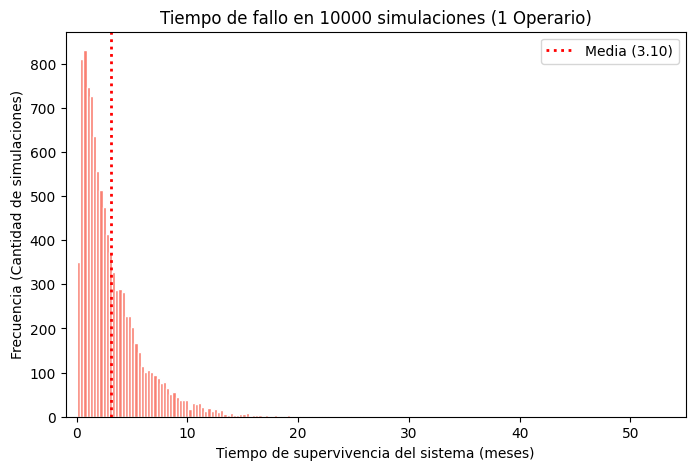

In [4]:
# @title
# Punto 3
import matplotlib.pyplot as plt

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(333)

N_SIM = 10_000

datos_1_operario = [generar_t_fallo_1_operario() for _ in range(N_SIM)]

# Calculamos la media de esta muestra
media_grafico = sum(datos_1_operario) / N_SIM

plt.figure(figsize=(8, 5))

# Histograma principal
plt.hist(datos_1_operario, bins="auto", edgecolor="white", color="salmon")

# Línea punteada marcando dónde está el promedio
plt.axvline(x=media_grafico, color="red", linestyle='dotted', linewidth=2, label=f'Media ({media_grafico:.2f})')

plt.xlim(-1,55)
plt.title(f"Tiempo de fallo en {N_SIM} simulaciones (1 Operario)")
plt.xlabel("Tiempo de supervivencia del sistema (meses)")
plt.ylabel("Frecuencia (Cantidad de simulaciones)")
plt.legend()
plt.show()

In [5]:
# @title
# Prueba de Bondad de Ajuste
import scipy.stats as st

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(333)

datos_1_operario = [generar_t_fallo_1_operario() for _ in range(10000)]
test_bondad_ajuste(datos_1_operario)

Ajuste a distribución Weibull:
- Estadístico D : 0.0145
- P-valor       : 2.9033e-02

Ajuste a distribución Gamma:
- Estadístico D : 0.0287
- P-valor       : 1.3459e-07


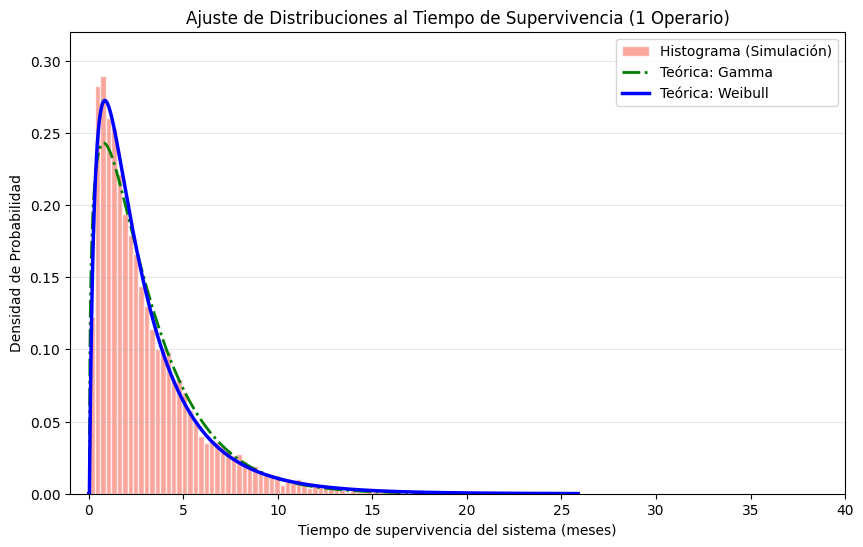

In [6]:
# @title
# Grafico
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(333)

N_SIM = 10_000

datos_1_operario = [generar_t_fallo_1_operario() for _ in range(N_SIM)]

plt.figure(figsize=(10, 6))

plt.hist(datos_1_operario, bins="auto", edgecolor="white", color="salmon",
         density=True, alpha=0.7, label='Histograma (Simulación)')

x = np.linspace(0, max(datos_1_operario), 1000)

# CURVA GAMMA
parametros_gamma = st.gamma.fit(datos_1_operario)
pdf_gamma = st.gamma.pdf(x, *parametros_gamma)

plt.plot(x, pdf_gamma, color='green', linestyle='-.', linewidth=2, label='Teórica: Gamma')

# CURVA WEIBULL
parametros_weibull = st.exponweib.fit(datos_1_operario)
pdf_weibull = st.exponweib.pdf(x, *parametros_weibull)

plt.plot(x, pdf_weibull, color='blue', linestyle='-', linewidth=2.5, label='Teórica: Weibull')

plt.xlim(-1,40)
plt.ylim(0,0.32)
plt.title(f"Ajuste de Distribuciones al Tiempo de Supervivencia (1 Operario)")
plt.xlabel("Tiempo de supervivencia del sistema (meses)")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

---

### Ejercicio 2. Problema de Reparación con dos operarios
El supermercado desea aumentar el tiempo medio del sistema y para esto analiza la posibilidad de contratar dos operarios, o bien comprar otra caja extra como repuesto. Para estudiar cual es la mejor alternativa, reconsidere el problema de reparación asumiendo que el taller tiene dos operarios igualmente idóneos que
trabajan en paralelo.

1. Escribir un programa para simular el modelo de reparación con dos colas.

2. Inicializar el programa con los tiempos de fallos de cada una las cajas en uso, y ejecutarlo para estimar el tiempo medio de fallo del sistema y su correspondiente desviación estándar. Utilizar nuevamente $N = 7, S = 3$ y que el tiempo medio de fallo de una caja es de un mes. Suponga nuevamente cada
operario del taller emplea un tiempo aleatorio con distribución exponencial de media igual a $1/8$ de mes para brindar servicio a una caja descompuesta.

3. Construir un histograma con los tiempos de fallo a partir de $10000$ simulaciones. Analizar las características del histograma.

4. Comparar los resultados con la situación en que se agregue una máquina de repuesto en lugar de agregar un operario. Realizar pruebas de bondad de ajuste para ambas situaciones.

---

In [7]:
# @title
# Punto 1
import math
from typing import Callable

def reparacion_2_operarios_paralelo(
        n: int,
        s: int,
        t_funcionamiento: Callable[[], float],
        t_reparacion_operario_1: Callable[[], float],
        t_reparacion_operario_2: Callable[[], float]
    ):
    # Inicialización
    t, r = 0, 0

    # Arreglo de tiempos de funcionamiento de las cajas registradoras
    T = []
    for _ in range(n):
        T.append(t + t_funcionamiento())
    T.sort()

    # Tiempo en el cual estará reparada una caja registradora por el operario 1 y 2
    t_estrella_1 = math.inf
    t_estrella_2 = math.inf

    while r <= s:
        evento_prox = min(min(T), t_estrella_1, t_estrella_2)

        if evento_prox in T:  # Fallo una caja registradora
            t = evento_prox
            r += 1

            # Se rompió la caja registradora i
            i = T.index(evento_prox)

            if r > s:
                break

            if t_estrella_1 == math.inf:
                t_estrella_1 = t + t_reparacion_operario_1()
            elif t_estrella_2 == math.inf:
                t_estrella_2 = t + t_reparacion_operario_2()

            T[i] = math.inf

        elif evento_prox == t_estrella_1:  # El operario 1 reparo una caja registradora
            t = t_estrella_1
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j
            T[j] = t + t_funcionamiento()

            if r > 0 and (t_estrella_2 == math.inf or r > 1):
                # Hay cajas registradoras rotas y el segundo técnico no esta
                # reparando ninguna o hay que reparar mas de una.

                t_estrella_1 = t + t_reparacion_operario_1()
            else:
                # No hay que repara nada o el segundo técnico esta reparando la
                # única caja registradora rota

                t_estrella_1 = math.inf

            T.sort()

        else:  # evento_prox == t_estrella_2 - El operario 2 reparo una caja registradora
            t = t_estrella_2
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j
            T[j] = t + t_funcionamiento()

            if r > 0 and (t_estrella_1 == math.inf or r > 1):
                # Hay cajas registradoras rotas y el primer técnico no esta
                # reparando ninguna o hay que reparar mas de una.

                t_estrella_2 = t + t_reparacion_operario_2()
            else:
                # No hay que repara nada o el primer técnico esta reparando la
                # única caja registradora rota

                t_estrella_2 = math.inf

            T.sort()

    return t

In [8]:
# @title
import numpy as np

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(333)

# Punto 2
def t_funcionamiento():
    return -math.log(1 - np.random.random()) * 1

def t_reparacion_operario_1():
    return -math.log(1 - np.random.random()) / 8

def t_reparacion_operario_2():
    return -math.log(1 - np.random.random()) / 8


def generar_t_fallo_2_operarios(n=7, s=3):
    return reparacion_2_operarios_paralelo(
            n, s, t_funcionamiento, t_reparacion_operario_1, t_reparacion_operario_2
        )

N_SIM = 10_000
datos = [generar_t_fallo_2_operarios() for _ in range(N_SIM)]

media = np.mean(datos)

# Cálculo de la desviación estándar muestral, es decir, dividido por (n - 1)
s = np.std(datos, ddof=1)

print(f"Media: {media:.4f}")
print(f"Desviación Estándar: {s:.4f}")

Media: 7.4332
Desviación Estándar: 7.3120


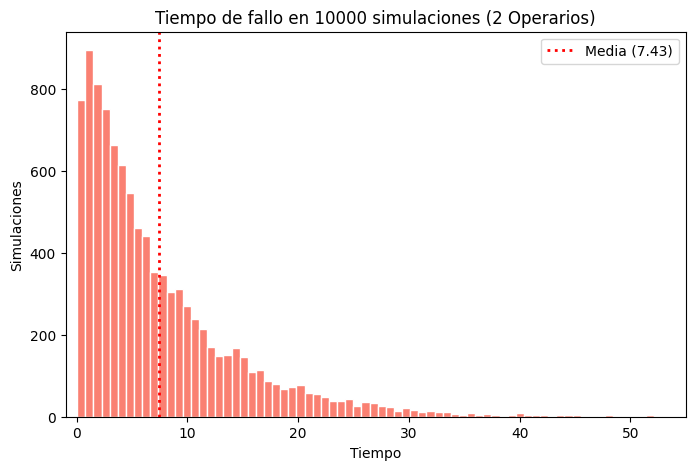

In [9]:
# @title
# Punto 3
import matplotlib.pyplot as plt

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(333)

N_SIM = 10_000
datos_2_operarios = [generar_t_fallo_2_operarios() for _ in range(N_SIM)]
media = np.mean(datos_2_operarios)

plt.figure(figsize=(8, 5))
plt.hist(datos_2_operarios, bins="auto", edgecolor="white", color="salmon")

plt.axvline(x=media, color="red", linestyle='dotted', linewidth=2, label=f'Media ({media:.2f})')

plt.xlim(-1,55)
plt.title(f"Tiempo de fallo en {N_SIM} simulaciones (2 Operarios)")
plt.xlabel("Tiempo")
plt.ylabel("Simulaciones")
plt.legend()
plt.show()

In [10]:
# @title
# Punto 4 - Prueba de Bondad de Ajuste

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(333)

N_SIM = 10_000
datos_2o_7n_3s = [generar_t_fallo_2_operarios() for _ in range(N_SIM)]
datos_1o_7n_4s = [generar_t_fallo_1_operario(7, 4) for _ in range(N_SIM)]

print("Prueba de bondad de Ajuste para el caso 'Se añade 1 operario'")
test_bondad_ajuste(datos_2o_7n_3s)

print()
print("Prueba de bondad de Ajuste para el caso 'Se añade 1 caja registradora'")
test_bondad_ajuste(datos_1o_7n_4s)


Prueba de bondad de Ajuste para el caso 'Se añade 1 operario'
Ajuste a distribución Weibull:
- Estadístico D : 0.0098
- P-valor       : 2.9325e-01

Ajuste a distribución Gamma:
- Estadístico D : 0.0205
- P-valor       : 4.4091e-04

Prueba de bondad de Ajuste para el caso 'Se añade 1 caja registradora'
Ajuste a distribución Weibull:
- Estadístico D : 0.0165
- P-valor       : 8.5493e-03

Ajuste a distribución Gamma:
- Estadístico D : 0.0213
- P-valor       : 2.2250e-04


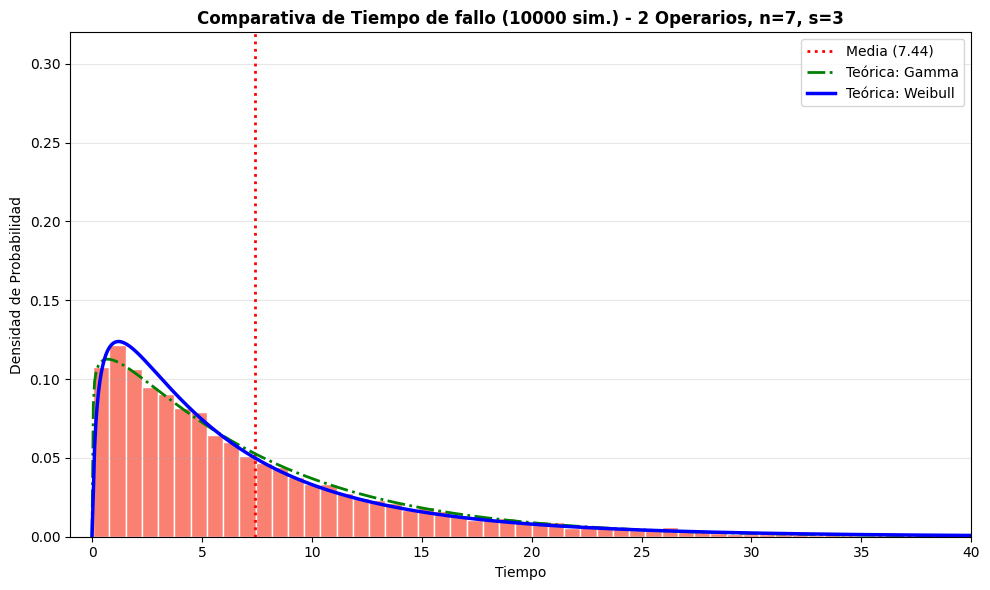

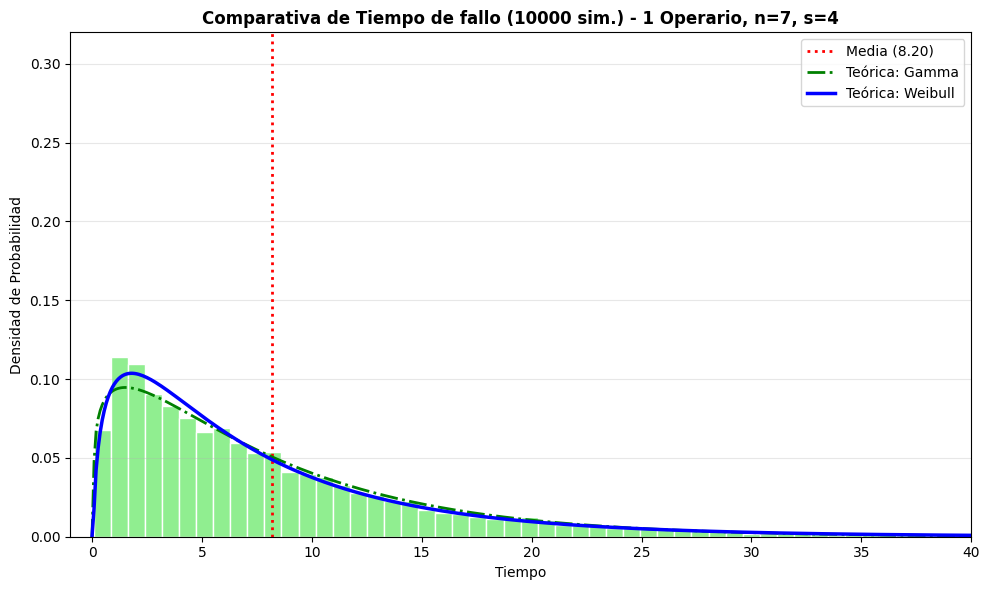

----------------------------------------
ESTADÍSTICAS: 2 operarios, n=7, s=3
Media: 7.4354
Desviación Estándar: 7.1702
----------------------------------------
ESTADÍSTICAS: 1 operario, n=7, s=4
Media: 8.1997
Desviación Estándar: 7.8195
----------------------------------------


In [11]:
# @title
# Punto 4 - Comparación entre añadir 1 operario o añadir 1 caja registradora de repuesto
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

# Se fija una semilla para poder replicar las simulaciones
np.random.seed(1)

N_SIM = 10_000

# Datos para 2 operarios
datos_2_op = [generar_t_fallo_2_operarios() for _ in range(N_SIM)]
media_2_op = np.mean(datos_2_op)

# Datos para 1 maquina de mas
datos_1_op = [generar_t_fallo_1_operario(7, 4) for _ in range(N_SIM)]
media_1_op = np.mean(datos_1_op)

limite_x_max = max(max(datos_2_op), max(datos_1_op)) * 1.05
LIMITES_X = (-1, 40)
LIMITES_Y = (0, 0.32)

plt.figure(figsize=(10, 6))

plt.hist(datos_2_op, bins="auto", edgecolor="white", color="salmon", density=True)
plt.axvline(x=media_2_op, color="red", linestyle='dotted', linewidth=2, label=f'Media ({media_2_op:.2f})')

x_2 = np.linspace(0, max(datos_2_op), 1000)

# CURVA GAMMA
parametros_gamma_2 = st.gamma.fit(datos_2_op)
pdf_gamma_2 = st.gamma.pdf(x_2, *parametros_gamma_2)
plt.plot(x_2, pdf_gamma_2, color='green', linestyle='-.', linewidth=2, label='Teórica: Gamma')

# CURVA WEIBULL
parametros_weibull_2 = st.exponweib.fit(datos_2_op)
pdf_weibull_2 = st.exponweib.pdf(x_2, *parametros_weibull_2)
plt.plot(x_2, pdf_weibull_2, color='blue', linestyle='-', linewidth=2.5, label='Teórica: Weibull')

plt.title("Comparativa de Tiempo de fallo (10000 sim.) - 2 Operarios, n=7, s=3", fontweight='bold')
plt.ylabel("Densidad de Probabilidad")
plt.xlabel("Tiempo")

plt.xlim(LIMITES_X)
plt.ylim(LIMITES_Y)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

plt.hist(datos_1_op, bins="auto", edgecolor="white", color="lightgreen", density=True)
plt.axvline(x=media_1_op, color="red", linestyle='dotted', linewidth=2, label=f'Media ({media_1_op:.2f})')

x_1 = np.linspace(0, max(datos_1_op), 1000)

# CURVA GAMMA
parametros_gamma_1 = st.gamma.fit(datos_1_op)
pdf_gamma_1 = st.gamma.pdf(x_1, *parametros_gamma_1)
plt.plot(x_1, pdf_gamma_1, color='green', linestyle='-.', linewidth=2, label='Teórica: Gamma')

# CURVA WEIBULL
parametros_weibull_1 = st.exponweib.fit(datos_1_op)
pdf_weibull_1 = st.exponweib.pdf(x_1, *parametros_weibull_1)
plt.plot(x_1, pdf_weibull_1, color='blue', linestyle='-', linewidth=2.5, label='Teórica: Weibull')

plt.title("Comparativa de Tiempo de fallo (10000 sim.) - 1 Operario, n=7, s=4", fontweight='bold')
plt.ylabel("Densidad de Probabilidad")
plt.xlabel("Tiempo")

plt.xlim(LIMITES_X)
plt.ylim(LIMITES_Y)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("-" * 40)
print("ESTADÍSTICAS: 2 operarios, n=7, s=3")
print(f"Media: {media_2_op:.4f}")
print(f"Desviación Estándar: {np.std(datos_2_op, ddof=1):.4f}")
print("-" * 40)
print("ESTADÍSTICAS: 1 operario, n=7, s=4")
print(f"Media: {media_1_op:.4f}")
print(f"Desviación Estándar: {np.std(datos_1_op, ddof=1):.4f}")
print("-" * 40)